In [5]:
import pandas as pd 
import re
df = pd.read_csv("clean_jobs.csv")
skill_taxonomy = pd.read_csv("skill_taxonomy.csv")

print("Jobs:", df.shape)
print("skills:", skill_taxonomy.shape)
print(skill_taxonomy.head())

Jobs: (7996, 17)
skills: (101, 3)
    skill     category          aliases
0  Python  Programming   python3|python
1    Java  Programming             java
2       C  Programming                c
3     C++  Programming  cpp|c plus plus
4      C#  Programming   csharp|c sharp


In [6]:
# create the skill list
skills = skill_taxonomy["skill"].dropna().tolist()
print(skills)

['Python', 'Java', 'C', 'C++', 'C#', 'JavaScript', 'TypeScript', 'R', 'HTML', 'CSS', 'React', 'Angular', 'Vue.js', 'Node.js', 'Express.js', 'Next.js', 'Tailwind CSS', 'SQL', 'MySQL', 'PostgreSQL', 'MongoDB', 'Oracle', 'Redis', 'Power BI', 'Tableau', 'Excel', 'Looker', 'Pandas', 'NumPy', 'Matplotlib', 'Seaborn', 'SciPy', 'Scikit-learn', 'TensorFlow', 'PyTorch', 'Keras', 'XGBoost', 'LightGBM', 'Apache Spark', 'Hadoop', 'Hive', 'Kafka', 'Databricks', 'AWS', 'Azure', 'GCP', 'Amazon EC2', 'Amazon S3', 'AWS Glue', 'Azure Data Factory', 'Git', 'GitHub', 'GitLab', 'Docker', 'Kubernetes', 'Jenkins', 'Terraform', 'Ansible', 'NLP', 'Transformers', 'BERT', 'GPT', 'Hugging Face', 'spaCy', 'NLTK', 'LangChain', 'Cybersecurity', 'Network Security', 'Ethical Hacking', 'Penetration Testing', 'Wireshark', 'Basic Computer Knowledge', 'Computer Fundamentals', 'MS Office', 'MS Word', 'PowerPoint', 'Internet', 'Email Handling', 'Data Entry', 'Typing', 'English Typing', 'Data Collection', 'Data Processing', '

# create the extractor

In [7]:
def extract_skills(text):
    found = []

    if pd.isna(text):
        return found

    text = str(text).lower()

    for _, row in skill_taxonomy.iterrows():

        skill = str(row["skill"]).strip()
        aliases = str(row["aliases"]).split(",")

        # Main skill + aliases
        terms = [skill] + [alias.strip() for alias in aliases]

        for term in terms:

            if not term or term == "nan":
                continue

            # Word boundary matching
            pattern = r"\b" + re.escape(term.lower()) + r"\b"

            if re.search(pattern, text):
                found.append(skill)
                break

    return list(dict.fromkeys(found))

In [8]:
text = df["clean_description"].iloc[0]
print(text)
result = extract_skills(text)
print("Extracted skills:")
print(result)

job description send me jobs like this qualifications 10th to graduation any skill basic computer knowledge job requirement system or laptop type of job full time or part time languages tamil english experience freshers experience payment details 1 form per day 5 10 form per day 50 100 form per day 500 monthly you can earn 15000 per month selection process easy selection process so what are you waiting for apply now grab best opportunity to make your carrier to improve your earing skills more detail contact mr hari salary inr 1 50 000 2 25 000 p a industry media entertainment internet functional area ites bpo kpo lpo customer service operations role category other role fresher keyskills english typing part time data entry selection process desired candidate profile education ug b tech b e any specialization pg any postgraduate any specialization post graduation not required please refer to the job description above company profile mm media pvt ltd mass media international find live inf

In [9]:
df["dictionary_skills"] = df["clean_description"].apply(
    extract_skills
)

In [10]:
df[["clean_description", "dictionary_skills"]].head()


,clean_description,dictionary_skills
0,job description send me jobs like this qualifi...,"[Basic Computer Knowledge, Internet, Data Entr..."
1,job description send me jobs like this qualifi...,"[Basic Computer Knowledge, Data Entry, Data Co..."
2,job description send me jobs like this as a de...,[SQL]
3,job description send me jobs like this involve...,[C]
4,job description send me jobs like this please ...,"[Java, JavaScript, HTML, Angular, MySQL, Git]"


In [14]:
df.to_csv("clean_jobs_with_skills.csv", index=False)

In [15]:
for col in df.columns:
    if "skill" in col.lower():
        print(col)

skills
dictionary_skills


In [16]:
print(df.columns.tolist())

['company', 'education', 'experience', 'industry', 'jobdescription', 'jobid', 'joblocation_address', 'jobtitle', 'numberofpositions', 'payrate', 'postdate', 'site_name', 'skills', 'uniq_id', 'clean_description', 'original_length', 'clean_length', 'dictionary_skills']


In [18]:
print(df["dictionary_skills"].head().to_string())

0    [Basic Computer Knowledge, Internet, Data Entr...
1    [Basic Computer Knowledge, Data Entry, Data Co...
2                                                [SQL]
3                                                  [C]
4        [Java, JavaScript, HTML, Angular, MySQL, Git]


# count how many skills each job 

In [ ]:
df["skill_count"] = df["extracted_skills"].apply(len)
print(df["skill_count"].describe())

count    7996.000000
mean        2.254502
std         2.240987
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        19.000000
Name: skill_count, dtype: float64


# find jobs where no skills found 

In [ ]:
no_skill_jobs = df[
    df["skill_count"] == 0
]

print("Jobs with no extracted skills:",
      len(no_skill_jobs))

Jobs with no extracted skills: 1852


# Count most common extracted skills

In [ ]:
from collections import Counter

all_skills = []

for skill_list in df["extracted_skills"]:
    all_skills.extend(skill_list)

skill_counts = Counter(all_skills)

skill_counts_df = pd.DataFrame(
    skill_counts.items(),
    columns=["skill", "job_count"]
)

skill_counts_df = skill_counts_df.sort_values(
    "job_count",
    ascending=False
)

print(skill_counts_df.head(20))
  


               skill  job_count
21     Communication       2934
9         Operations       1635
15              Java        979
7                BPO        933
6   Customer Service        930
13               SQL        889
14                 C        875
10           English        720
8                KPO        705
30                 R        663
1           Internet        628
26            Oracle        614
36       Call Center        588
16        JavaScript        562
17              HTML        415
27             Excel        406
29               CSS        331
28         MS Office        311
25   Computer Vision        293
24               php        237


# visualization

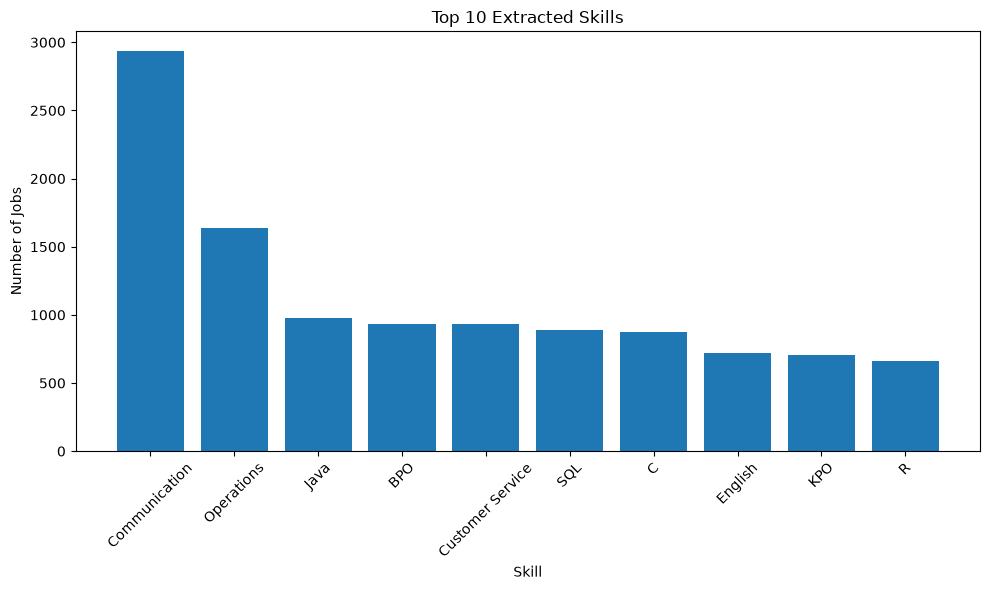

In [ ]:
import matplotlib.pyplot as plt

top_skills = skill_counts_df.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_skills["skill"],
    top_skills["job_count"]
)

plt.title("Top 10 Extracted Skills")
plt.xlabel("Skill")
plt.ylabel("Number of Jobs")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()